In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.__version__)

True
2
2.10.0+cu128


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    random_split
)

from torchvision import (
    datasets,
    transforms
)

from torchvision.models import resnet18 #resnet34 and resnet50

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

PyTorch Version: 2.10.0+cu128
GPU Available: True


In [3]:
data_dir = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"

train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)

In [4]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Validation and test should not use augmentation
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [10]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [11]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memory:", torch.cuda.get_device_properties(0).total_memory / 1024**3, "GB")

CUDA Available: True
GPU: Tesla T4
Memory: 14.56219482421875 GB


In [14]:
import torch
import torch.nn as nn

# ============================================================
# Residual Block
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)

            )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))

        out = self.relu(self.bn2(self.conv2(out)))

        out = self.bn3(self.conv3(out))

        out += identity

        out = self.relu(out)

        return out


# ============================================================
# Enhanced ResNet39
# ============================================================

class EnhancedResNet39(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.in_channels = 32

        self.conv1 = nn.Conv2d(
            3,
            32,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(32)

        self.relu = nn.ReLU(inplace=True)

        # Stage 1

        self.layer1 = self.make_layer(
            32,
            blocks=4,
            stride=1
        )

        # Stage 2

        self.layer2 = self.make_layer(
            64,
            blocks=4,
            stride=2
        )

        # Stage 3

        self.layer3 = self.make_layer(
            128,
            blocks=4,
            stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(
            128,
            num_classes
        )

        # He Initialization

        for m in self.modules():

            if isinstance(m,nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(m,nn.BatchNorm2d):

                nn.init.constant_(m.weight,1)

                nn.init.constant_(m.bias,0)

    def make_layer(
        self,
        out_channels,
        blocks,
        stride
    ):

        layers=[]

        layers.append(

            ResidualBlock(
                self.in_channels,
                out_channels,
                stride
            )

        )

        self.in_channels=out_channels

        for _ in range(1,blocks):

            layers.append(

                ResidualBlock(
                    self.in_channels,
                    out_channels
                )

            )

        return nn.Sequential(*layers)

    def forward(self,x):

        x=self.relu(self.bn1(self.conv1(x)))

        x=self.layer1(x)

        x=self.layer2(x)

        x=self.layer3(x)

        x=self.avgpool(x)

        x=torch.flatten(x,1)

        x=self.dropout(x)

        x=self.fc(x)

        return x


# ============================================================
# Create Model
# ============================================================

device=torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model=EnhancedResNet39(
    num_classes=10
).to(device)

print(model)

total_params=sum(
    p.numel()
    for p in model.parameters()
)

trainable_params=sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal Parameters : {total_params:,}")

print(f"Trainable Parameters : {trainable_params:,}")

EnhancedResNet39(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EnhancedResNet39(num_classes=10).to(device)

print(model)

EnhancedResNet39(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [18]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved : {torch.cuda.memory_reserved()/1024**2:.2f} MB")

Allocated: 10.15 MB
Reserved : 38.00 MB


In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

In [21]:
for images, labels in train_loader:

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

In [22]:
EPOCHS = 7

best_val_acc = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    # ============================
    # TRAINING
    # ============================

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)

    epoch_train_acc = 100 * correct / total

    train_losses.append(epoch_train_loss)

    train_accuracies.append(epoch_train_acc)

    # ============================
    # VALIDATION
    # ============================

    model.eval()

    running_val_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)

    epoch_val_acc = 100 * val_correct / val_total

    val_losses.append(epoch_val_loss)

    val_accuracies.append(epoch_val_acc)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Train Acc: {epoch_train_acc:.2f}% "
        f"Val Loss: {epoch_val_loss:.4f} "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )

    if epoch_val_acc > best_val_acc:

        best_val_acc = epoch_val_acc

        torch.save(
            model.state_dict(),
            "best_EnhancedResNet39_model.pth"
        )

        print("⭐ Best Model Saved")

Epoch [1/7] Train Loss: 0.7960 Train Acc: 72.81% Val Loss: 0.6322 Val Acc: 78.52%
⭐ Best Model Saved
Epoch [2/7] Train Loss: 0.6171 Train Acc: 79.86% Val Loss: 0.3643 Val Acc: 88.05%
⭐ Best Model Saved
Epoch [3/7] Train Loss: 0.5302 Train Acc: 83.03% Val Loss: 0.3571 Val Acc: 88.57%
⭐ Best Model Saved
Epoch [4/7] Train Loss: 0.4575 Train Acc: 85.55% Val Loss: 0.2756 Val Acc: 90.91%
⭐ Best Model Saved
Epoch [5/7] Train Loss: 0.3935 Train Acc: 87.50% Val Loss: 0.2538 Val Acc: 92.07%
⭐ Best Model Saved
Epoch [6/7] Train Loss: 0.3706 Train Acc: 88.36% Val Loss: 0.2558 Val Acc: 91.14%
Epoch [7/7] Train Loss: 0.3351 Train Acc: 89.54% Val Loss: 0.2550 Val Acc: 91.31%


In [24]:
model.load_state_dict(torch.load("best_EnhancedResNet39_model.pth"))
model.eval()

EnhancedResNet39(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [25]:
import torch

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print(f"Overall Accuracy : {accuracy*100:.2f}%")

Overall Accuracy : 91.23%


In [31]:
from sklearn.metrics import classification_report

class_names = test_dataset.dataset.classes

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

          AnnualCrop     0.9303    0.9047    0.9173       472
              Forest     0.9728    0.9706    0.9717       442
HerbaceousVegetation     0.8490    0.9083    0.8776       458
             Highway     0.8460    0.9412    0.8910       391
          Industrial     0.9905    0.8280    0.9020       378
             Pasture     0.8973    0.8763    0.8866       299
       PermanentCrop     0.8043    0.8786    0.8398       379
         Residential     0.9453    0.9600    0.9526       450
               River     0.9388    0.8587    0.8969       375
             SeaLake     0.9752    0.9680    0.9716       406

            accuracy                         0.9123      4050
           macro avg     0.9149    0.9094    0.9107      4050
        weighted avg     0.9159    0.9123    0.9128      4050



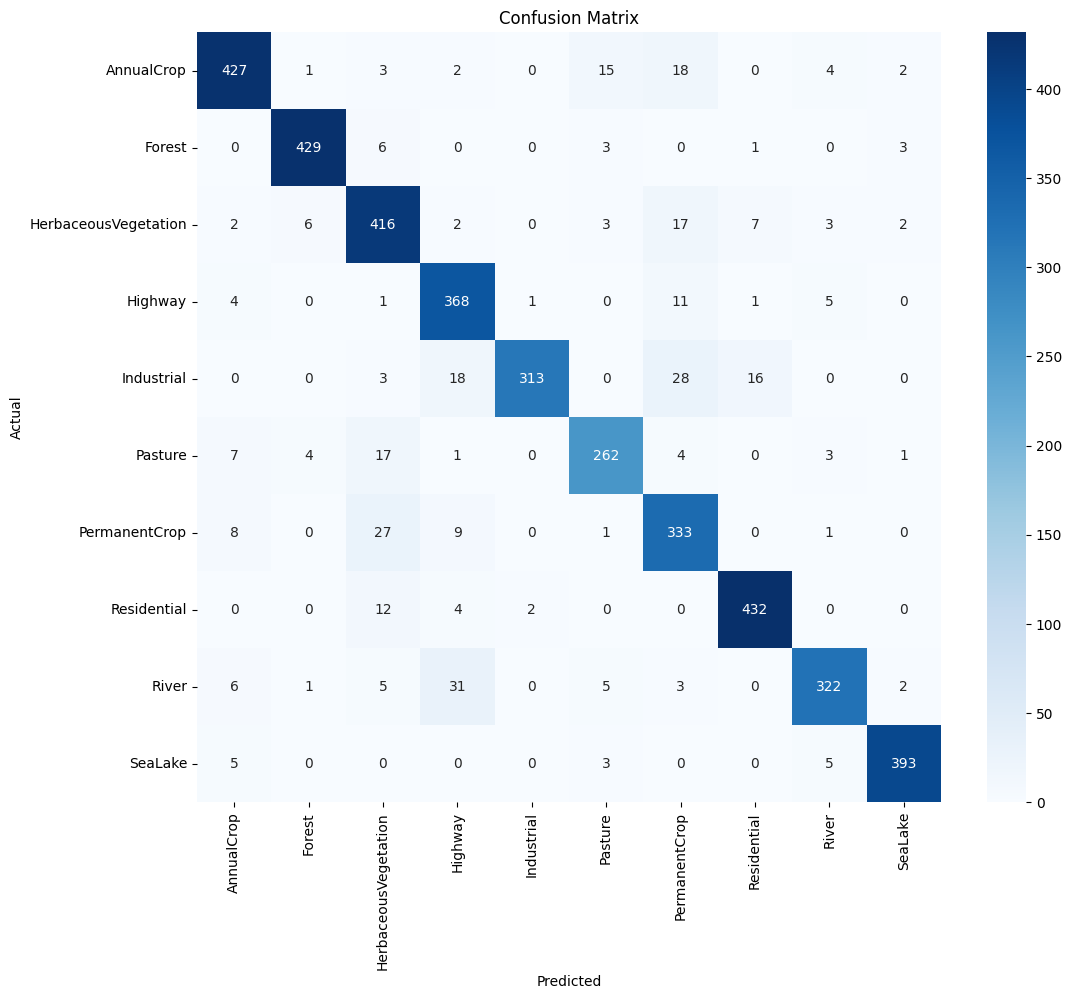

In [32]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

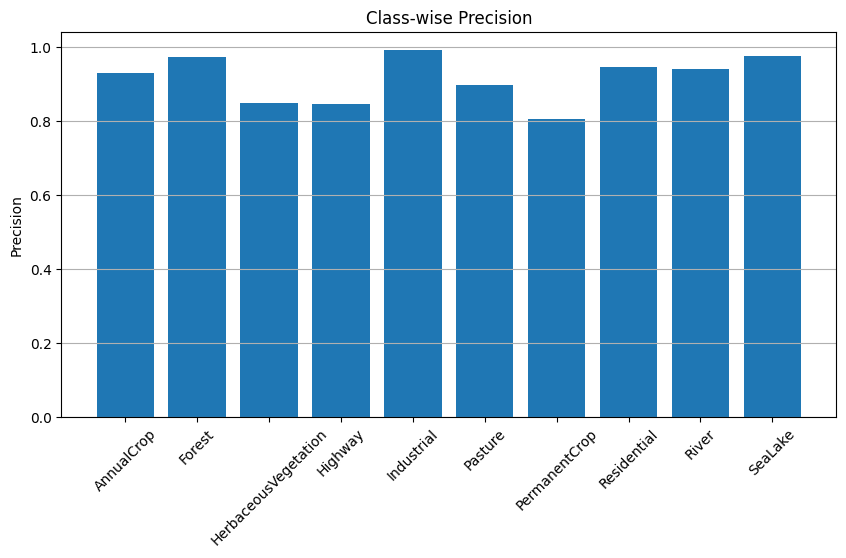

In [33]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred
)

plt.figure(figsize=(10,5))

plt.bar(class_names, precision)

plt.title("Class-wise Precision")

plt.ylabel("Precision")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

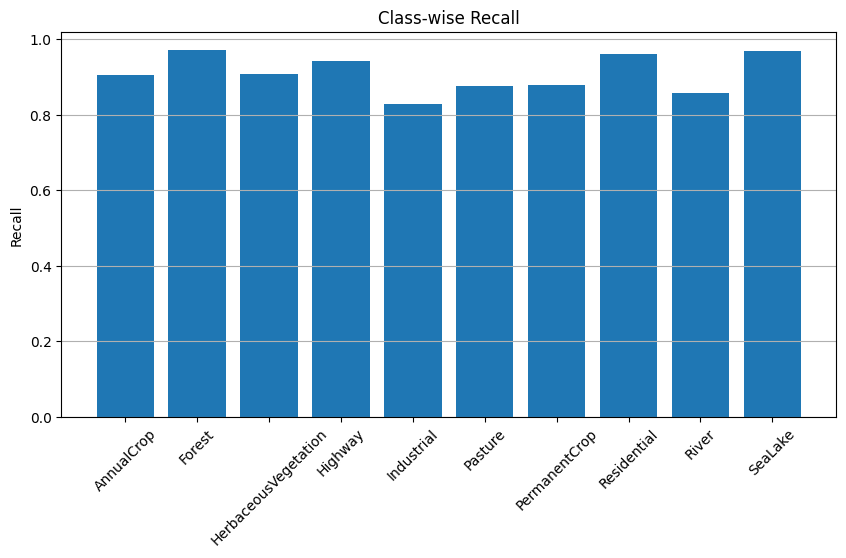

In [34]:
plt.figure(figsize=(10,5))

plt.bar(class_names, recall)

plt.title("Class-wise Recall")

plt.ylabel("Recall")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

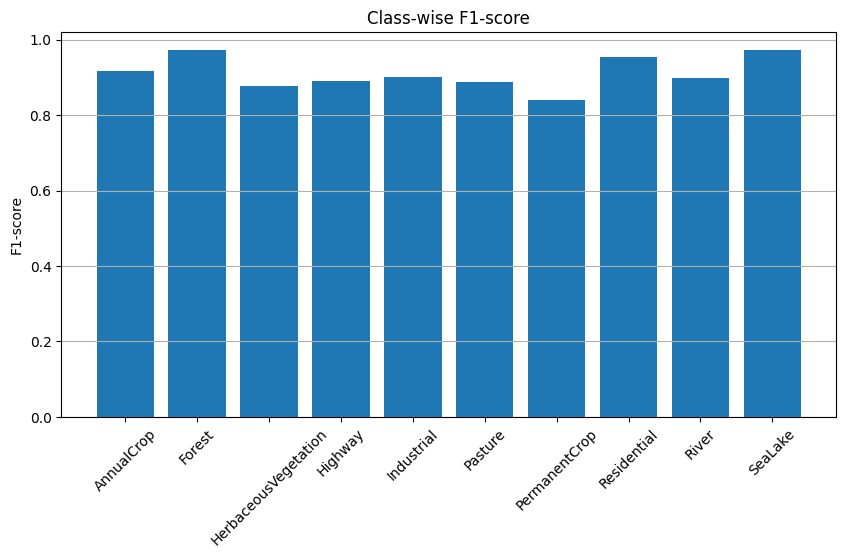

In [35]:
plt.figure(figsize=(10,5))

plt.bar(class_names, f1)

plt.title("Class-wise F1-score")

plt.ylabel("F1-score")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

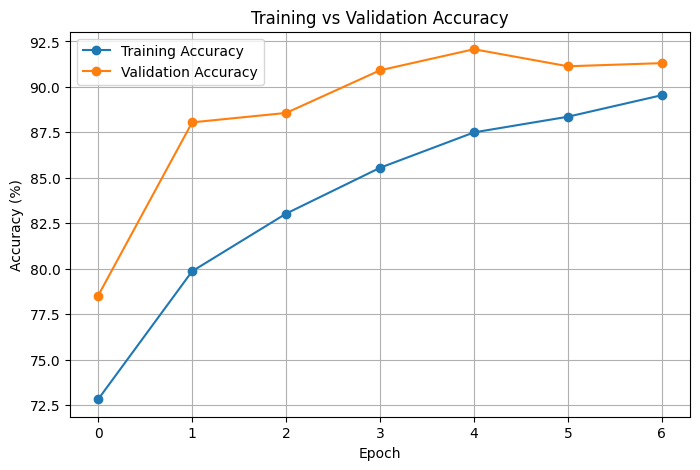

In [36]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy", marker="o")

plt.plot(val_accuracies, label="Validation Accuracy", marker="o")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

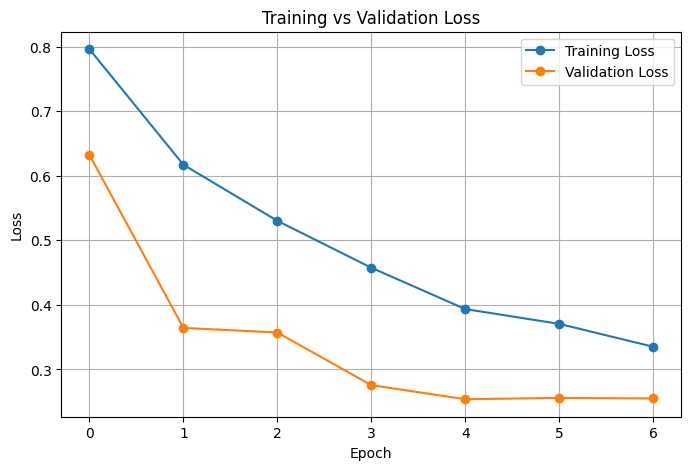

In [37]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss", marker="o")

plt.plot(val_losses, label="Validation Loss", marker="o")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()